# Task 11: Markov Chains for Text

**Goal**: Understand state transitions and random walks in text sequences.  
**Practice**: Build a word-level transition matrix from financial news, visualize the next-state distribution for a high-entropy seed word, and generate text via a random walk.

In [1]:
from pathlib import Path
import json
import csv
import re
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd() / "datasets"

def load_financial_sentences(path):
    raw = path.read_bytes()

    text = None
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            text = raw.decode(enc)
            break
        except UnicodeDecodeError:
            continue
    if text is None:
        raise UnicodeDecodeError("decode", b"", 0, 1, "Cannot decode financial dataset")

    # Try JSON first
    try:
        obj = json.loads(text)
        if isinstance(obj, dict) and "articles" in obj:
            return [str(x) for x in obj["articles"] if str(x).strip()]
        if isinstance(obj, list):
            return [str(x) for x in obj if str(x).strip()]
    except json.JSONDecodeError:
        pass

    # Fallback: CSV-like lines sentiment,"sentence"
    sentences = []
    for row in csv.reader(text.splitlines()):
        if not row:
            continue
        if len(row) >= 2:
            sentences.append(row[1].strip())
        else:
            sentences.append(row[0].strip())
    return [s for s in sentences if s]

articles = load_financial_sentences(DATA_DIR / "financial_news.csv")

print(f"Total sentences loaded: {len(articles)}")
print("\nSample sentences:")
for s in articles[:3]:
    print(" ", s)

# Tokenization for generation: keep function words for grammatical flow
text = " ".join(articles).lower()
raw_tokens = re.findall(r'\b[a-z][a-z0-9\-]*\b', text)
raw_tokens = [t for t in raw_tokens if len(t) >= 2 and not t.isdigit()]

# For Markov text generation, do NOT remove stopwords.
# Keep grammar words; only remove extremely rare noise.
freq = Counter(raw_tokens)
tokens = [t for t in raw_tokens if freq[t] >= 2]

print(f"\nRaw tokens: {len(raw_tokens)}, After light filtering: {len(tokens)}")
print(f"Vocabulary size: {len(set(tokens))}")
print("Top-20 frequent tokens:", [w for w, _ in Counter(tokens).most_common(20)])

Total sentences loaded: 4846

Sample sentences:
  According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
  Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .
  The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .

Raw tokens: 90218, After light filtering: 85185
Vocabulary size: 4664
Top-20 frequent tokens: ['the', 'of', 'in', 'and', 'to', 'for', 'eur', 'is', 'will', 'company', 'from', 'on', 'its', 'has', 'with', 'by', 'said', 'as', 'be', 'mn']


### Step 1: Building the Transition Matrix
In a first-order Markov Chain, the probability of transitioning to the next state (word) depends ONLY on the current state.
$$P(w_{t+1} | w_1, w_2, \dots, w_t) = P(w_{t+1} | w_t)$$

Instead of a dense $V \times V$ matrix (which would be mostly zeros and consume too much memory), we build a sparse representation using nested dictionaries to store the transition probabilities.

In [2]:
def build_transition_matrix(tokens, n=2):
    transitions = defaultdict(Counter)
    for i in range(len(tokens) - n):
        state = tuple(tokens[i : i + n])
        next_word = tokens[i + n]
        transitions[state][next_word] += 1
    return transitions

def normalize_transitions(transitions):
    transition_probs = {}
    for state, next_counts in transitions.items():
        total = sum(next_counts.values())
        # Calculate raw probabilities without Laplace smoothing for text generation
        transition_probs[state] = {
            w: count / total
            for w, count in next_counts.items()
        }
    return transition_probs

# 2nd-order Markov chain: (w_t, w_{t+1}) -> w_{t+2}
transitions = build_transition_matrix(tokens, n=2)
# Using raw probabilities to prevent random hallucinations and dead ends
transition_probs = normalize_transitions(transitions)

print(f"Number of states (2-word contexts): {len(transition_probs)}")

Number of states (2-word contexts): 41259


### Step 2: Visualizing Transitions
We automatically select the seed word with the highest transition entropy — meaning its outgoing distribution is the most spread-out and informative. Let's look at the top-12 most likely next states for that word.

We also inspect the transitions for the task's canonical seed words **`stock`**.

--- Statistics for word: 'stock' ---
Total occurrences of 'stock': 94
  Next word 'exchange': 45 times
  Next word 'option': 14 times
  Next word 'options': 9 times
  Next word 'of': 3 times
  Next word 'rose': 2 times
  Next word 'in': 2 times
  Next word 'was': 2 times
  Next word 'has': 1 times
  Next word 'increase': 1 times
  Next word 'mobile': 1 times
  Next word 'price': 1 times
  Next word 'however': 1 times


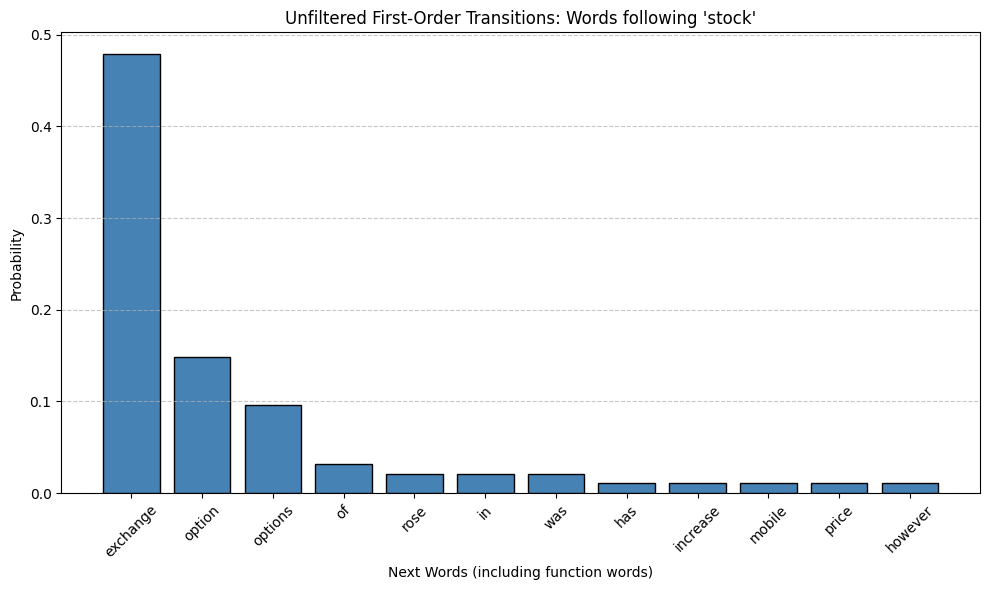

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Build a first-order transition matrix (state = single word)
def build_first_order_matrix(tokens):
    transitions = defaultdict(Counter)
    for i in range(len(tokens) - 1):
        state = tokens[i]
        next_word = tokens[i + 1]
        transitions[state][next_word] += 1
    return transitions

def get_probabilities(transitions):
    probs = {}
    for state, next_counts in transitions.items():
        total = sum(next_counts.values())
        probs[state] = {word: count / total for word, count in next_counts.items()}
    return probs

# Initialize the model using the unfiltered tokens from your previous cell
transitions = build_first_order_matrix(tokens)
transition_probs = get_probabilities(transitions)

# Visualization: Raw statistics for words following "stock"
target_word = "stock"

if target_word in transitions:
    next_counts = transitions[target_word]
    
    # Show top 12 most frequent next words without any filtering
    top_k = 12
    sorted_items = sorted(next_counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
    
    words = [x[0] for x in sorted_items]
    counts = [x[1] for x in sorted_items]
    
    # Calculate probabilities for the plot
    total_occurrences = sum(next_counts.values())
    probs = [c / total_occurrences for c in counts]

    print(f"--- Statistics for word: '{target_word}' ---")
    print(f"Total occurrences of '{target_word}': {total_occurrences}")
    for w, c in sorted_items:
        print(f"  Next word '{w}': {c} times")

    plt.figure(figsize=(10, 6))
    plt.bar(words, probs, color='steelblue', edgecolor='black')
    plt.title(f"Unfiltered First-Order Transitions: Words following '{target_word}'")
    plt.xlabel("Next Words (including function words)")
    plt.ylabel("Probability")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"Word '{target_word}' not found in the corpus.")

### Step 3: Random Walk Text Generation
A **Random Walk** simulates moving through the Markov Chain. We start at a seed node and probabilistically sample the next node at each step based on our transition matrix.  
Unlike Greedy Search (which always picks the highest-probability next word), random walk samples from the full distribution, producing varied outputs.

In [4]:
def random_walk(seed, probs, max_len=15):
    if seed not in probs:
        return [seed]
    
    walk = [seed]
    current_state = seed
    
    for _ in range(max_len - 1):
        next_choices = probs.get(current_state)
        if not next_choices:
            break
            
        words = list(next_choices.keys())
        p_values = list(next_choices.values())
        
        # Probabilistic sampling based on the transition matrix
        next_word = np.random.choice(words, p=p_values)
        walk.append(next_word)
        current_state = next_word
        
    return walk

print("\n--- Unfiltered Random Walks starting from 'market' ---")
np.random.seed(42) # For reproducibility
for i in range(3):
    generated_tokens = random_walk("market", transition_probs, max_len=12)
    sentence = " ".join(generated_tokens).capitalize() + "."
    print(f"  Walk {i+1}: {sentence}")


--- Unfiltered Random Walks starting from 'market' ---
  Walk 1: Market with one site and technology company is buyer capman made in.
  Walk 2: Market strong market is part of directors sarantel has received major markets.
  Walk 3: Market in operating profit an agreement said it has wide selection of.
